# Deep Reinforcement Learning Laboratory

In this laboratory session we will work on getting more advanced versions of Deep Reinforcement Learning algorithms up and running. Deep Reinforcement Learning is **hard**, and getting agents to stably train can be frustrating and requires quite a bit of subtlety in analysis of intermediate results. We will start by refactoring (a bit) my implementation of `REINFORCE` on the [Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). 

## Exercise 1: Improving my `REINFORCE` Implementation (warm up)

In this exercise we will refactor a bit and improve some aspects of my `REINFORCE` implementation. 

**First Things First**: Spend some time playing with the environment to make sure you understand how it works.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical


import pygame
_ = pygame.init()


print("✅ Tutto importato con successo!")
print(f"-> Versione PyTorch: {torch.__version__}")
print(f"-> Versione Gymnasium: {gym.__version__}")
print(f"-> Versione NumPy: {np.__version__}")
print(f"-> La GPU (CUDA) è attiva? {torch.cuda.is_available()}")

✅ Tutto importato con successo!
-> Versione PyTorch: 2.12.0+cu130
-> Versione Gymnasium: 1.3.0
-> Versione NumPy: 2.2.5
-> La GPU (CUDA) è attiva? True


In [2]:
# Instantiate a rendering and a non-rendering environment.
env_render = gym.make('CartPole-v1', render_mode='human')
env = gym.make('CartPole-v1')

In [5]:
state, info = env.reset()
print(f"Initial state of the cartpole: {state}\n")

Initial state of the cartpole: [-0.03123018  0.03495623  0.01483921  0.0100431 ]



### Code to TEST how long it lasts when choosing **randomly**

In [ ]:
punteggio_totale = 0
partita_finita = False
passo = 0

In [ ]:
while not partita_finita:
    passo += 1
    
    # Scegliamo un'azione a caso: 0 (sinistra) o 1 (destra)
    azione_casuale = env.action_space.sample()
    
    # Eseguiamo l'azione nell'ambiente
    prossimo_stato, premio, terminato, troncato, info = env.step(azione_casuale)
    
    punteggio_totale += premio
    
    # Stampiamo i primi 3 passi per capire cosa succede
    if passo <= 3:
        print(f"--- PASSO {passo} ---")
        print(f"Azione scelta: {azione_casuale} (0=Sinistra, 1=Destra)")
        print(f"Nuovo Stato: {prossimo_stato}")
        print(f"Premio ricevuto: {premio}")
        print(f"Palo caduto? {terminato} | Tempo scaduto? {troncato}\n")
        
    # La partita finisce se il palo cade (terminato) o se finiscono i passi massimi (troncato)
    partita_finita = terminato or troncato

print("----------------------------------------")
print(f"Partita terminata dopo {passo} passi.")
print(f"Punteggio totale ottenuto dall'agente casuale: {punteggio_totale}")

# 4. Chiudiamo l'ambiente per liberare la memoria
env.close()

**Next Things Next**: Now get your `REINFORCE` implementation working on the environment. You can import my (probably buggy and definitely inefficient) implementation here. Or even better, refactor an implementation into a separate package from which you can `import` the stuff you need here. 

### **IMPORTING** the package where I put all the used function for RL training

In [2]:
from drl_lab.networks import PolicyNetwork
from drl_lab.algorithms import reinforce, run_episode,reinforce_baseline
from drl_lab.evaluation import evaluate_policy

In [ ]:

"""NOTA: Prima di creare l'ambiente nella tua cella, aggiungi questa variabile d'ambiente per disabilitare il driver audio di SDL (il motore dietro Pygame):pythonimport os
# Tell Pygame/SDL to ignore audio hardware completely
os.environ["SDL_AUDIODRIVER"] = "dummy"

# Adesso puoi lanciare il codice di prima senza vedere i messaggi ALSA
import gymnasium as gym
env_render = gym.make('CartPole-v1', render_mode='human')"""



# 1. Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Instantiate a (rendering) CartPole environment
env_render = gym.make('CartPole-v1', render_mode='human')
import pygame
pygame.display.init()  

# 3. Make a policy network and MOVE IT TO GPU
policy = PolicyNetwork()
policy = policy.to(device) # <--- THIS IS THE FIX

# 4. Run the episodes
for _ in range(10):
    run_episode(env_render, policy, device=device) # Ensure run_episode knows the device
    
# 5. Close and cleanup
env_render.close()
pygame.display.quit()

In [ ]:
# 1. Force CPU device
device = torch.device("cpu")
seed = 2112
torch.manual_seed(seed)
np.random.seed(seed)

# 2. Initialize environments
env = gym.make('CartPole-v1')
env.reset(seed=seed)
env_render = None 

pygame.display.init()

# 3. Make a policy network on CPU
policy = PolicyNetwork()
policy = policy.to(device) # Moved to CPU

# 4. Train the agent (Ensure your reinforce function receives device="cpu")
rewards_history = reinforce_baseline(policy, env, env_render, gamma=0.99, num_episodes=1000, device="cpu")

# 5. Plot results
plt.plot(rewards_history)
plt.xlabel('Episodes')
plt.ylabel('Running Reward')
plt.title('REINFORCE Training Curve (CPU)')
plt.show()

env.close()
pygame.display.quit()


In [ ]:
env_render = gym.make('CartPole-v1', render_mode='human')
for _ in range(10):
    run_episode(env_render, policy, device="cpu")
env_render.close()

**Last Things Last**: My implementation does a **super crappy** job of evaluating the agent performance during training. The running average is not a very good metric. Modify my implementation so that every $N$ iterations (make $N$ an argument to the training function) the agent is run for $M$ episodes in the environment. Collect and return: (1) The average **total** reward received over the $M$ iterations; and (2) the average episode length. Analyze the performance of your agents with these new metrics.

In [3]:
import os
os.environ["SDL_AUDIODRIVER"] = "dummy"

import wandb
import omegaconf
from omegaconf import OmegaConf

#wandb.login() #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

cfg = OmegaConf.load("config.yaml")

# --- Setup ---
seed = 2112
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cpu")
env = gym.make('CartPole-v1')
env.reset(seed=seed)

policy = PolicyNetwork(state_dim=4, action_dim=2, hidden_dim=128).to(device)

wandb.init(
    project=cfg.experiment.project,
    name=cfg.experiment.name,
    config=OmegaConf.to_container(cfg, resolve=True)
)


# Train with robust evaluation
history = reinforce(
    policy=policy,
    env=env,
    gamma=cfg.training.gamma,
    num_episodes=cfg.training.num_episodes,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    device=cfg.training.device,
    use_wandb=cfg.logging.use_wandb,               # <--- Attiva il logging
    checkpoint_dir=cfg.logging.checkpoint_dir       # <--- Attiva il salvataggio
)

env.close()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/tomma/.netrc.
wandb: Currently logged in as: tommypasto (Tommy_team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[Ep    0] Train:   52.0 | Eval:   36.8
   💾 New best model saved!
[Ep   50] Train:   59.0 | Eval:  145.7
   💾 New best model saved!
[Ep  100] Train:   49.0 | Eval:   42.3
[Ep  150] Train:   63.0 | Eval:  186.1
   💾 New best model saved!
[Ep  200] Train:  433.0 | Eval:  423.1
   💾 New best model saved!
[Ep  250] Train:  500.0 | Eval:  500.0
   💾 New best model saved!
[Ep  300] Train:  500.0 | Eval:  500.0
[Ep  350] Train:  500.0 | Eval:  500.0
[Ep  400] Train:  500.0 | Eval:  496.7
[Ep  450] Train:  500.0 | Eval:  500.0
[Ep  500] Train:  500.0 | Eval:  500.0
[Ep  550] Train:  500.0 | Eval:  500.0
[Ep  600] Train:  319.0 | Eval:  500.0
[Ep  650] Train:  500.0 | Eval:  500.0
[Ep  700] Train:  500.0 | Eval:  500.0
[Ep  750] Train:  191.0 | Eval:  191.7
[Ep  800] Train:  500.0 | Eval:  497.1
[Ep  850] Train:  500.0 | Eval:  500.0
[Ep  900] Train:  500.0 | Eval:  500.0
[Ep  950] Train:  500.0 | Eval:  500.0


### **PLOTTING** results

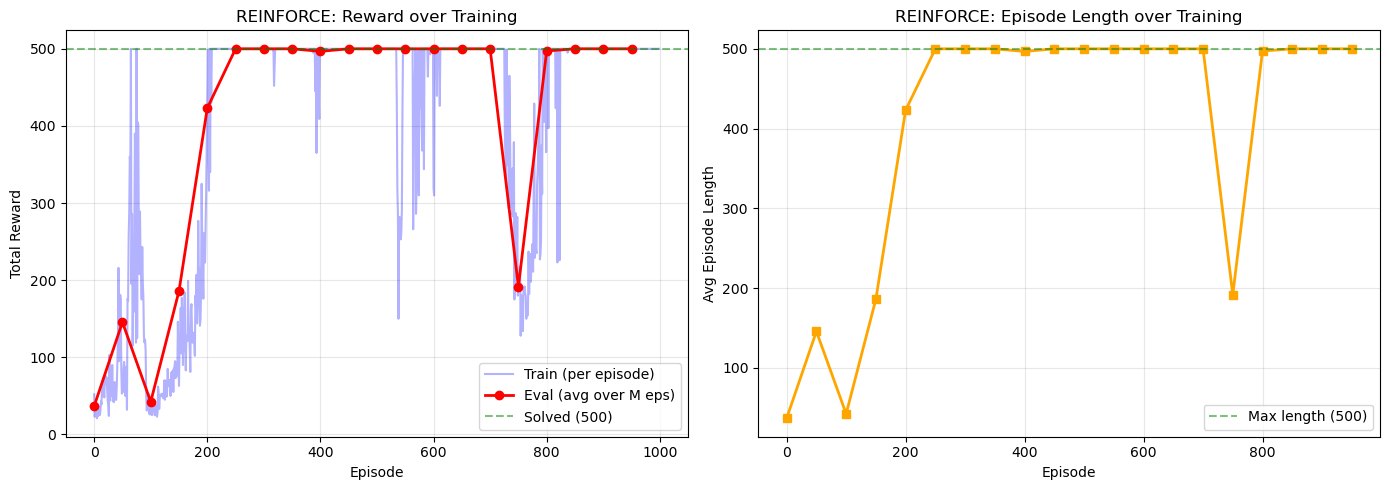

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training rewards (per episode) vs Evaluation rewards (every N episodes)
ax1.plot(history["train_rewards"], alpha=0.3, label="Train (per episode)", color="blue")
ax1.plot(history["eval_episodes"], history["eval_rewards"],
         marker="o", label="Eval (avg over M eps)", color="red", linewidth=2)
ax1.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Solved (500)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.set_title("REINFORCE: Reward over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluation episode lengths
ax2.plot(history["eval_episodes"], history["eval_lengths"],
         marker="s", color="orange", linewidth=2)
ax2.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Max length (500)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg Episode Length")
ax2.set_title("REINFORCE: Episode Length over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
import os
os.environ["SDL_AUDIODRIVER"] = "dummy" # Per evitare warning audio su Kaggle/Linux

import gymnasium as gym
import torch
import pygame

# 1. Setup ambiente di rendering
env_render = gym.make('CartPole-v1', render_mode='human')
pygame.display.init()

# 2. Metti la policy in modalità valutazione (anche se qui non cambia molto i pesi)
policy.eval()

# 3. Loop di visualizzazione DETERMINISTICA (Greedy)
with torch.no_grad(): # Disabilita il calcolo dei gradienti per velocità
    obs, _ = env_render.reset()
    done = False
    
    while not done:
        obs_tensor = torch.from_numpy(obs).float().unsqueeze(0).to(device)
        
        # --- IL TRUCCO: Argmax invece di Sample ---
        probs = policy(obs_tensor)
        action = torch.argmax(probs, dim=-1).item() # Scegli sempre la migliore!
        # ------------------------------------------
        
        obs, reward, terminated, truncated, _ = env_render.step(action)
        done = terminated or truncated
        
        # Pausa leggera per rendere la visualizzazione godibile (opzionale)
        pygame.time.wait(10) 

env_render.close()
pygame.display.quit()
print("Visualizzazione completata!")

Visualizzazione completata!


-----
## Exercise 2: `REINFORCE` with a Value Baseline (warm up)

In this exercise we will augment my implementation (or your own) of `REINFORCE` to subtract a baseline from the target in the update equation in order to stabilize (and hopefully speed-up) convergence. For now we will stick to the Cartpole environment.



**First Things First**: Recall from the slides on Deep Reinforcement Learning that we can **subtract** any function that doesn't depend on the current action from the q-value without changing the (maximum of our) objecttive function $J$:  

$$ \nabla J(\boldsymbol{\theta}) \propto \sum_{s} \mu(s) \sum_a \left( q_{\pi}(s, a) - b(s) \right) \nabla \pi(a \mid s, \boldsymbol{\theta}) $$

In `REINFORCE` this means we can subtract from our target $G_t$:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - b(S_t)) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

Since we are only interested in the **maximum** of our objective, we can also **rescale** our target by any function that also doesn't depend on the action. A **simple baseline** which is even independent of the state -- that is, it is **constant** for each episode -- is to just **standardize rewards within the episode**. So, we **subtract** the average return and **divide** by the variance of returns:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha \left(\frac{G_t - \bar{G}}{\sigma_G}\right) \nabla  \pi(A_t \mid s, \boldsymbol{\theta}) $$

This baseline is **already** implemented in my implementation of `REINFORCE`. Experiment with and without this standardization baseline and compare the performance. We are going to do something more interesting.

In [1]:
# Your code here. Modify your implementation of `REINFORCE` to optionally use the standardize baseline.

**The Real Exercise**: Standard practice is to use the state-value function $v(s)$ as a baseline. This is intuitively appealing -- we are more interested in updating out policy for returns that estimate the current **value** worse. Our new update becomes:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - \tilde{v}(S_t \mid \mathbf{w})) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

where $\tilde{v}(s \mid \mathbf{w})$ is a **deep neural network** with parameters $w$ that estimates $v_\pi(s)$. What neural network? Typically, we use the **same** network architecture as that of the Policy.

**Your Task**: Modify your implementation to fit a second, baseline network to estimate the value function and use it as **baseline**. 

In [2]:
# Your code here.


-----

## Exercise 3: Going Deeper

As usual, pick **AT LEAST ONE** of the following exercises to complete.

### Exercise 3.1: Solving Cartpole and Lunar Lander with A2C (easy)

Implement the Advantage Actor-Critic (A2C) algorithm and use it to solve both `Cartpole` (to validate your implementation) and the [Lunar Lander Environment](https://gymnasium.farama.org/environments/box2d/lunar_lander/). This environment is a little bit harder than Cartpole, but not much. Make sure you perform the appropriate types of analyses to quantify and qualify the performance of your agents.

**Why choose this exercise?** A2C is a good, "pure" TD-based reinforcement learning algorithm and is the basis for more advanced Policy Gradient approaches. Having a good understanding of it is a good starting point for diving into the state-of-the-art in on-policy Deep Reinforcement Learning.


### Exercise 3.2: Solving Cartpole and Lunar Lander with `Deep Q-Learning` (harder)

On policy Deep Reinforcement Learning tends to be **very unstable**. Write an implementation (or adapt an existing one) of `Deep Q-Learning` to solve these two environments (Cartpole and Lunar Lander). To do this you will need to implement a **Replay Buffer** and use a second, slow-moving **target Q-Network** to stabilize learning.

**Why choose this exercise?** DQL, similarly to A2C, provides a good starting point for diving into the state-of-the-art in *off-policy* Deep Reinforcement Learning algorithms.

### Exercise 3.3: Solving the OpenAI CarRacing environment (hardest) 

Use `Deep Q-Learning` -- or even better, an off-the-shelf implementation of **Proximal Policy Optimization (PPO)** -- to train an agent to solve the [OpenAI CarRacing](https://github.com/andywu0913/OpenAI-GYM-CarRacing-DQN) environment. This will be the most *fun*, but also the most *difficult*. Some tips:

1. Make sure you use the `continuous=False` argument to the environment constructor. This ensures that the action space is **discrete** (we haven't seen how to work with continuous action spaces).
2. Your Q-Network will need to be a CNN. A simple one should do, with two convolutional + maxpool layers, folowed by a two dense layers. You will **definitely** want to use a GPU to train your agents.
3. The observation space of the environment is a single **color image** (a single frame of the game). Most implementations stack multiple frames (e.g. 3) after converting them to grayscale images as an observation.

**Why choose this exercise?** This exercise is a good simulation of a *real* Deep Reinforcement Learning problem that involves both *perception* and *action* -- just like the problems you might find in the wild. It will require you to think carefully about monitoring performance during training and carefully adapting hyperparameters to learn a good policy for this environment.


### Exercise 3.4: Instruction Fine-tuning an LLM (very hard)

In this exercise you will adapt a small LLM (e.g. `Qwen/Qwen3-0.6B-Base`) on one or more procedural reasoning tasks from the [Reasoning Gym](https://github.com/open-thought/reasoning-gym/tree/main). Adapting LLMs with Reinforcement Learning, however, requires a **ton** of infrastructural code for wrangling data, managing replay buffers, and coordinating batch construction and masking. Thus, it was not possible to come up with a reasonably-dimensioned exercise that can be done *from scratch* like the ones above.

However, for this exercise, you can use the [RLHF Book](https://github.com/natolambert/rlhf-book/tree/main) by Nathan Lambert as a basis for your experimentation. The book contains a wealth of information and -- most importantly -- *code* for implementing RLHF pipelines.

**The Exercise**: Pick an (easy) dataset from the Reasoning Gym, and adapt Qwen to solve it. Anything goes. This is an experimental exercise for this year, so learn something and *have fun*.

**Important**: Just copying the RLHF Book repository and running the code is, obviously, not an acceptable solution for this exercise. I expect you to *reuse* the code from the repository and do something (minimally) different than what is already in the repository. And, as always, whatever you submit, you must be able to explain *everything* it doe.
 